## Problem 1
In the first two figures, you will plot the allele frequencies in the admixed popula-
tion against the CEU or YRI. Comparing the two plots, what are your observations?

The plots below show a linear relationship between the admixed population and the CEU as the plot is clustered around a diagonal line y=x, which suggests these populations are similar.
The second plot shows more scattered frequencies, suggesting the admixed population compared to the YRI is more different. Therefore the admixed population may be made up of more CEU than YRI.

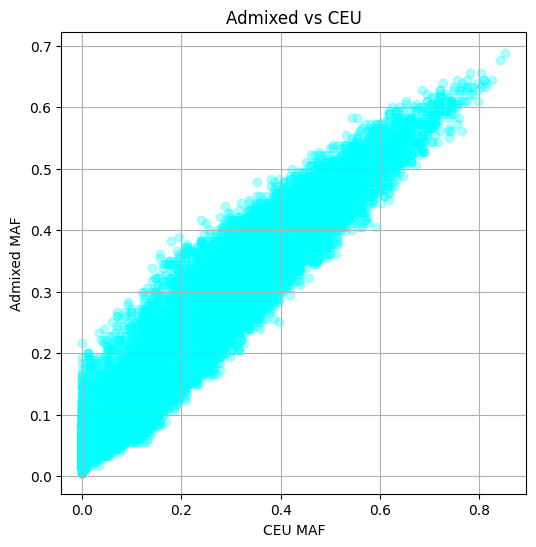

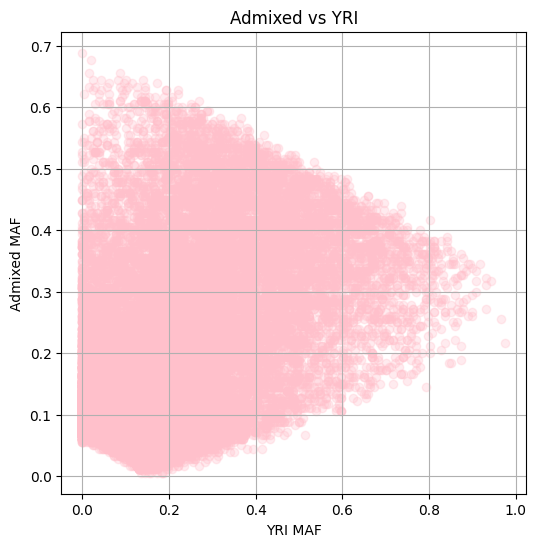

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the .frq files
admixed = pd.read_csv('admixed.chr1.frq', sep=r'\s+')
ceu     = pd.read_csv('CEU.chr1.frq', sep=r'\s+')
yri     = pd.read_csv('YRI.chr1.frq', sep=r'\s+')

# Extract Minor Allele Frequencies (MAF) from each population
pa = admixed['MAF'] 
pCEU = ceu['MAF']     
pYRI = yri['MAF']   

# Plot 1: Admixed vs CEU
plt.figure(figsize=(6, 6))
plt.scatter(pCEU, pa, alpha=0.3, label='Admixed vs CEU', color='cyan')
plt.xlabel('CEU MAF')
plt.ylabel('Admixed MAF')
plt.title('Admixed vs CEU')
plt.grid(True)
plt.show()

# Plot 2: Admixed vs YRI
plt.figure(figsize=(6, 6))
plt.scatter(pYRI, pa, alpha=0.3, label='Admixed vs YRI', color='pink')
plt.xlabel('YRI MAF')
plt.ylabel('Admixed MAF')
plt.title('Admixed vs YRI')
plt.grid(True)
plt.show()

## Problem 2
In the third figure, you will plot the SSE(α) for a range of α values and label the optimal admixture fraction in a different colour. Discuss why this approach could help estimate α.

This approach helps estimate alpha by comparing predicted allele frequencies (based on CEU and YRI) with the actual data from the admixed population. The alpha that minimises the Sum of Squared Errors (SSE) represents the best fit. The SSE plot clearly shows a minimum, making the optimal alpha easy to identify.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#define range of values 
alphas = np.arange(0.1, 1.0, 0.1)
sse_values = []

#predict admixed frequencies 
for alpha in alphas:
    p_alpha = alpha * pCEU + (1 - alpha) * pYRI
    sse = np.sum((pa - p_alpha) ** 2)
    sse_values.append(sse)
    
# Convert to numpy array
sse_values = np.array(sse_values)

# Find alpha with minimum SSE
min_sse_index = np.argmin(sse_values)
optimal_alpha = alphas[min_sse_index]

# Plot SSE vs alpha
plt.figure(figsize=(8, 6))
plt.plot(alphas, sse_values, marker='o')
plt.scatter(optimal_alpha, sse_values[min_sse_index], color='red', s=100, label=f'Optimal alpha = {optimal_alpha:.1f}')
plt.xlabel('Admixture fraction α (CEU proportion)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('SSE vs Admixture fraction α')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'pCEU' is not defined

## Problem 3
In the fourth figure, you will plot the predicted allele frequency using the optimal α
against the observed allele frequencies in the admixed population. 
What are the reasons that the predicted frequencies do not exactly match the observed frequencies?

The predicted frequencies do not match exactly, which could be due to genetic drift, or some could be influenced by selection, or mutations. An estimation error is also possible because allele frequencies in CEU, YRI, and admixed populations are estimates, not exact values.

In [3]:
# Recompute the predicted allele frequencies using optimal alpha
p_hat_optimal = optimal_alpha * pCEU + (1 - optimal_alpha) * pYRI

# Plot predicted vs observed
plt.figure(figsize=(6,6))
plt.scatter(pa, p_hat_optimal, alpha=0.5)
plt.xlabel("Observed Admixed Allele Frequency")
plt.ylabel("Predicted Allele Frequency")
plt.title("Predicted vs Observed Allele Frequencies\n(using optimal α = {:.2f})".format(optimal_alpha))
plt.grid(True)
plt.show()

NameError: name 'optimal_alpha' is not defined